In [ ]:
import pandas as pd


CSV_PATH = "/content/sample_data/titanic.csv"
df = pd.read_csv(CSV_PATH)


print("FIRST 5 ROWS")
print(df.head())


print("\nDATASET SHAPE")
print(df.shape)


print("\nCOLUMN NAMES")
print(df.columns)


print("\nDATA TYPES")
print(df.dtypes)


print("\nDATASET INFORMATION")
df.info()


print("\nSTATISTICAL SUMMARY")
print(df.describe())


print("\nMISSING VALUES")
print(df.isnull().sum())


print("\nDUPLICATE ROWS")
print(df.duplicated().sum())


print("\nSURVIVAL DISTRIBUTION")
print(df["survived"].value_counts())


print("\nSURVIVAL PERCENTAGE")
print(df["survived"].value_counts(normalize=True) * 100)

FIRST 5 ROWS
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

DATASET SHAPE
(891, 15)

COLUMN NAMES
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


csv_path = "/content/sample_data/titanic.csv"
min_acceptable_accuracy = 0.7

df = pd.read_csv(csv_path)


df["sex"] = df["sex"].map({"male": 0, "female": 1})


features = ["pclass", "sex", "age", "fare"]


df[features] = df[features].fillna(df[features].median())


X = df[features]
y = df["survived"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
}


def evaluate_model(model, X_train, y_train, X_test, y_test):
    """Fits a model and returns its test accuracy."""
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)


for name, model in models.items():
    acc = evaluate_model(model, X_train, y_train, X_test, y_test)

    if acc >= min_acceptable_accuracy:
        verdict = "GOOD"
    else:
        verdict = "NEEDS WORK"

    print(f"{name:<20} accuracy={acc:.3f} -> {verdict}")

Logistic Regression  accuracy=0.788 -> GOOD
Decision Tree        accuracy=0.765 -> GOOD


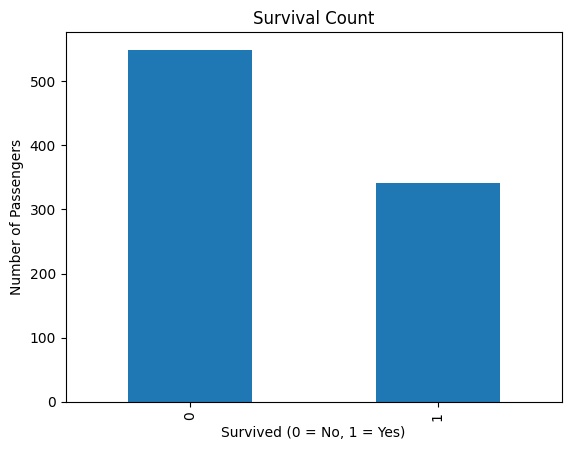

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/sample_data/titanic.csv")

df["survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

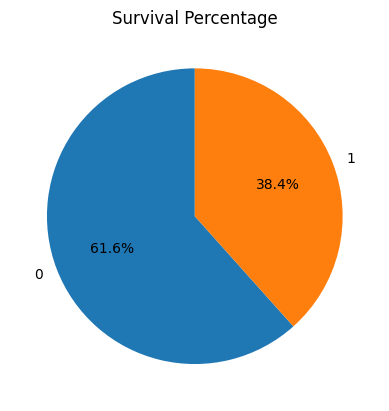

In [5]:
import matplotlib.pyplot as plt

df["survived"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Survival Percentage")
plt.ylabel("")
plt.show()

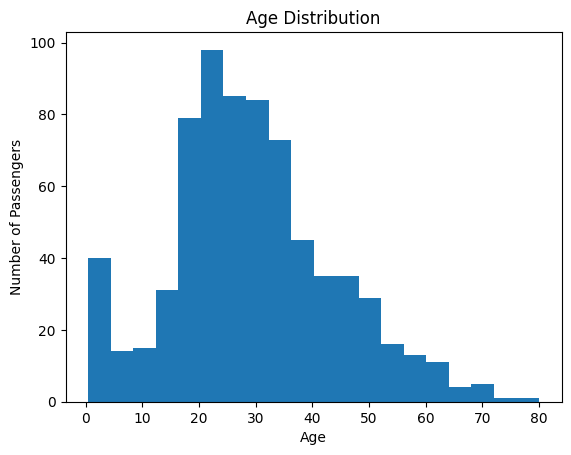

In [6]:
plt.hist(df["age"].dropna(), bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

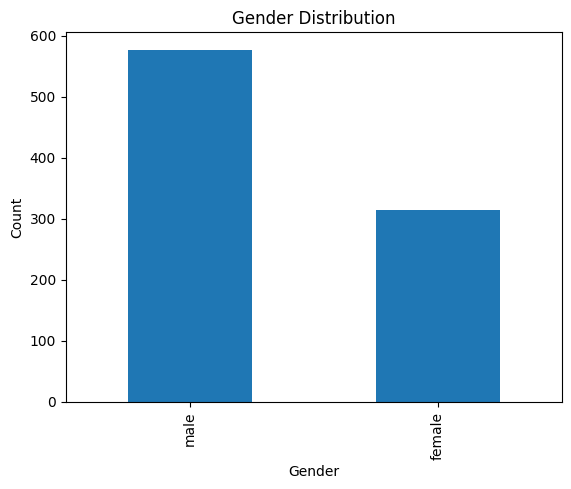

In [7]:
df["sex"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

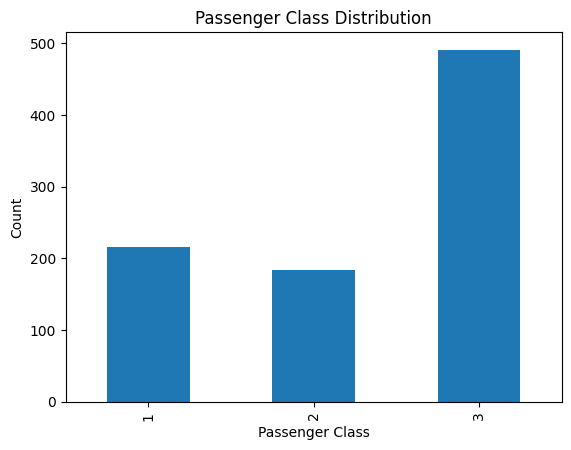

In [8]:
df["pclass"].value_counts().sort_index().plot(kind="bar")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

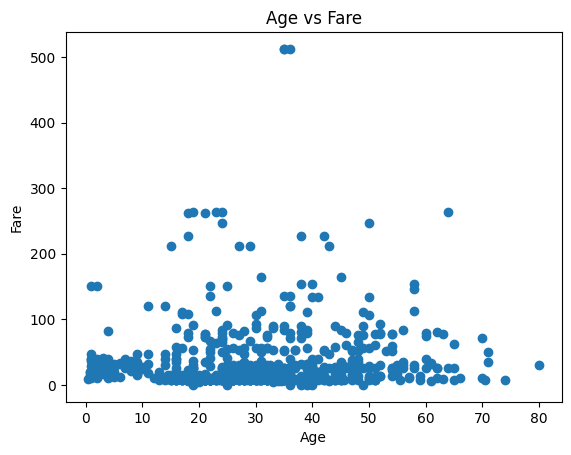

In [9]:
plt.scatter(df["age"], df["fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

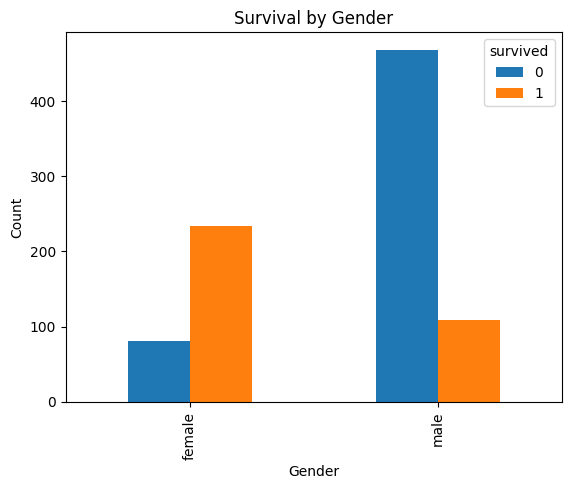

In [10]:
survival_gender = pd.crosstab(df["sex"], df["survived"])

survival_gender.plot(kind="bar")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

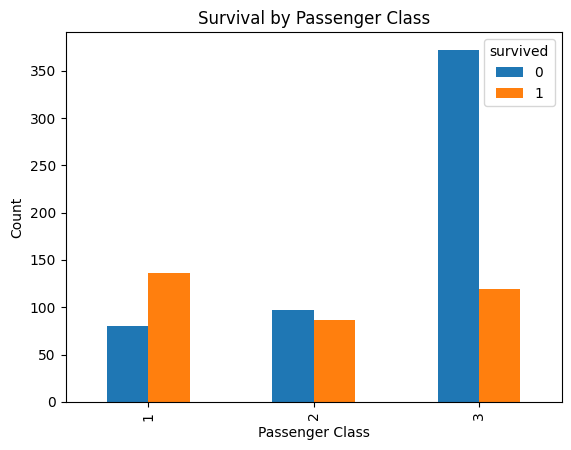

In [11]:
survival_class = pd.crosstab(df["pclass"], df["survived"])

survival_class.plot(kind="bar")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

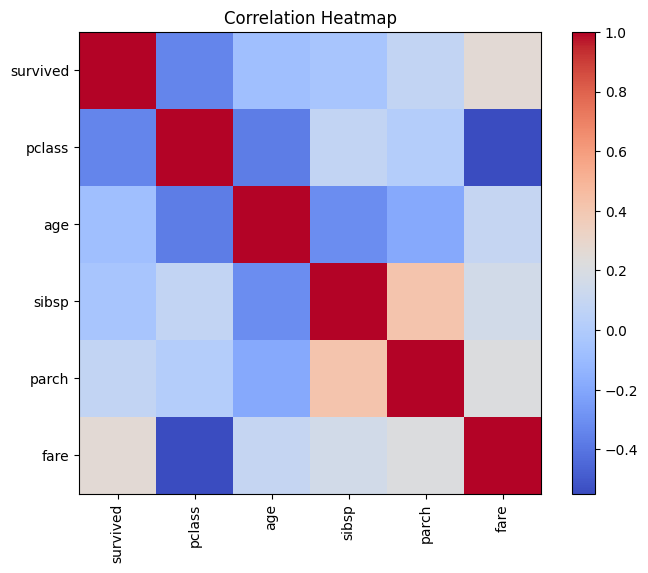

In [12]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))
plt.imshow(numeric_df.corr(), cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Heatmap")
plt.show()

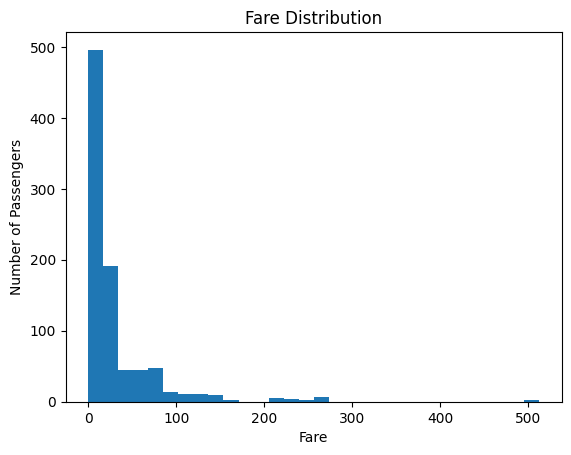

In [13]:
plt.hist(df["fare"], bins=30)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()